# HESE depth-dependent P_light functions (sigmoid_Tianlu)

`sigmoid_Tianlu` is the **P_light** function — the probability that a muon
with energy `E_mu` at the detector produces enough Cherenkov light to trigger
the HESE veto.

The low-energy floor `c ≈ 0.6–0.8` reflects real physics: even a slow muon
traversing IceCube's string array emits Cherenkov light and can trigger hits.
There is no sharp detection threshold — the floor encodes the irreducible
detection probability at very low muon energies.

Parametric form:
```
sigmoid_Tianlu(E_mu, k0, x0, c) = (1 - c) / (1 + exp(-k0 * (log10(E_mu) - x0))) + c
```
- `c`  : low-energy floor
- `x0` : inflection point in log10(E_mu / GeV)
- `k0` : steepness

Parameters are parsed directly from `pl.py` as text — no import needed.

In [18]:
import sys
sys.path = [p for p in sys.path if "rnaab" not in p]

import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

PL_PY = (
    "/home/rnaab/software/virtualenvs/nuveto/lib/python3.6/"
    "site-packages/nuVeto/resources/mu/pl.py"
)

PRPL_NPZ = (
    "/mnt/ceph1-npx/user/tvaneede/software/py_venvs/"
    "py3-v4.4.2_reco-v1.2.3_icetray-v1.16.0/lib/python3.12/"
    "site-packages/nuVeto/data/prpl/ice_allm97_step_1.npz"
)

def sigmoid_Tianlu(emu, k0, x0, c):
    return (1 - c) / (1 + np.exp(-k0 * (np.log10(emu) - x0))) + c

def depth_m(z):
    return 1948.0 - z

In [19]:
# Parse pl.py as text
with open(PL_PY) as fh:
    src = fh.read()

pattern = re.compile(
    r"def pl_hese_depth_(\w+)\(emu\):.*?"
    r"return sigmoid_Tianlu\(emu,"
    r"([\d.eE+\-]+),([\d.eE+\-]+),([\d.eE+\-]+)\)",
    re.DOTALL
)

entries = []
for m in pattern.finditer(src):
    suffix = m.group(1)
    k0 = float(m.group(2))
    x0 = float(m.group(3))
    c  = float(m.group(4))
    z  = -int(suffix[5:]) if suffix.startswith("minus") else int(suffix)
    entries.append({"z": z, "depth_m": depth_m(z), "k0": k0, "x0": x0, "c": c})

entries.sort(key=lambda e: e["depth_m"])
print(f"Parsed {len(entries)} depth slices")
print(f"Depth range: {entries[0]['depth_m']:.0f} – {entries[-1]['depth_m']:.0f} m")

Parsed 39 depth slices
Depth range: 1402 – 2454 m


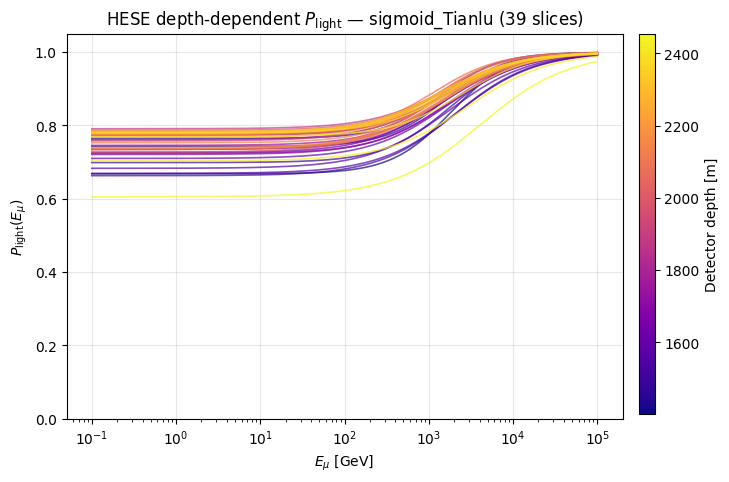

In [20]:
# P_light for all 39 depth slices
E_mu     = np.logspace(-1, 5, 500)   # 0.1 GeV – 100 TeV
depths_m = np.array([e["depth_m"] for e in entries])
cmap     = cm.plasma
norm     = plt.Normalize(depths_m.min(), depths_m.max())

fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(right=0.82)
cax = fig.add_axes([0.84, 0.12, 0.02, 0.76])

for e in entries:
    ax.plot(E_mu, sigmoid_Tianlu(E_mu, e["k0"], e["x0"], e["c"]),
            color=cmap(norm(e["depth_m"])), alpha=0.7, lw=1.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Detector depth [m]")

ax.set_xscale("log")
ax.set_xlabel(r"$E_\mu$ [GeV]")
ax.set_ylabel(r"$P_{\rm light}(E_\mu)$")
ax.set_ylim(0, 1.05)
ax.set_title(r"HESE depth-dependent $P_{\rm light}$ — sigmoid_Tianlu (39 slices)")
ax.grid(True, alpha=0.3)

plt.savefig("sigmoid_tianlu_plight.pdf", bbox_inches="tight")
plt.show()

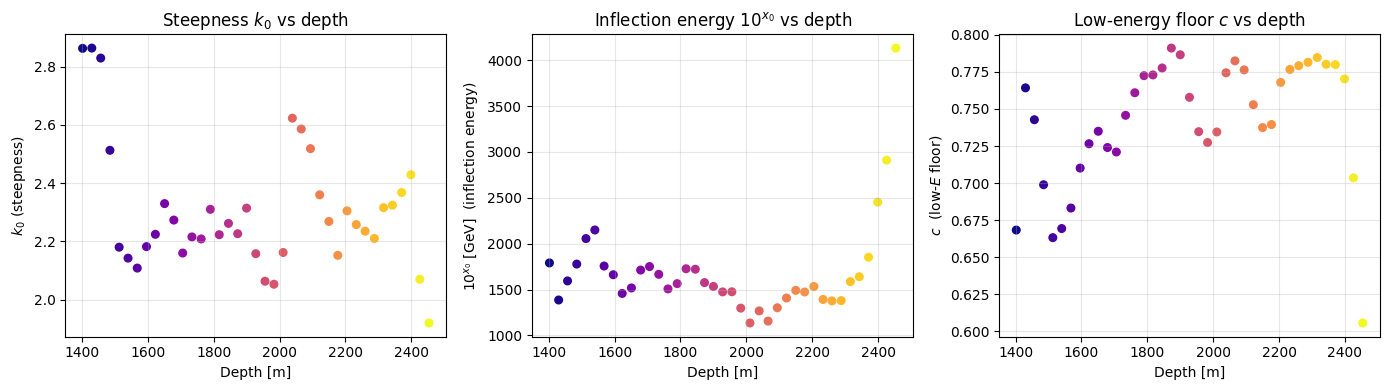

In [21]:
# Fit parameters vs depth
k0_arr = np.array([e["k0"] for e in entries])
x0_arr = np.array([e["x0"] for e in entries])
c_arr  = np.array([e["c"]  for e in entries])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sc_kw = dict(s=30, c=depths_m, cmap=cmap)

axes[0].scatter(depths_m, k0_arr, **sc_kw)
axes[0].set_ylabel(r"$k_0$ (steepness)")
axes[0].set_title(r"Steepness $k_0$ vs depth")

axes[1].scatter(depths_m, 10**x0_arr, **sc_kw)
axes[1].set_ylabel(r"$10^{x_0}$ [GeV]  (inflection energy)")
axes[1].set_title(r"Inflection energy $10^{x_0}$ vs depth")

axes[2].scatter(depths_m, c_arr, **sc_kw)
axes[2].set_ylabel(r"$c$  (low-$E$ floor)")
axes[2].set_title(r"Low-energy floor $c$ vs depth")

for ax in axes:
    ax.set_xlabel("Depth [m]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sigmoid_tianlu_parameters.pdf", bbox_inches="tight")
plt.show()

## What is actually stored in `ice_allm97_step_1`?

The file is a 2D array: **`prpl(ei, l)`** where
- `ei` = initial muon energy (GeV), range 266 GeV – 10⁸ GeV
- `l`  = ice column length (m) traversed by the muon, range 1000 – 200,000 m

There **is** depth dependence through `l`. Unlike the HESE depth-dependent files,
P_light is a fixed 1 TeV step regardless of depth.

In [22]:
import sys
sys.path = [p for p in sys.path if "rnaab" not in p]

import numpy as np
import matplotlib.pyplot as plt

data    = np.load(PRPL_NPZ, allow_pickle=True)
ei_grid = data['grid_0']   # initial muon energy [GeV]
l_grid  = data['grid_1']   # ice column length [m]
vals    = data['values']   # shape (n_ei, n_l)

print(f"ei: {len(ei_grid)} points,  {ei_grid.min():.1f} – {ei_grid.max():.2e} GeV")
print(f"l:  {len(l_grid)}  points,  {l_grid.min():.0f} – {l_grid.max():.0f} m")
print(f"values: min={vals.min():.4f}  max={vals.max():.4f}")

ei: 93 points,  265.6 – 1.00e+08 GeV
l:  100  points,  1000 – 200000 m
values: min=0.0000  max=1.0000


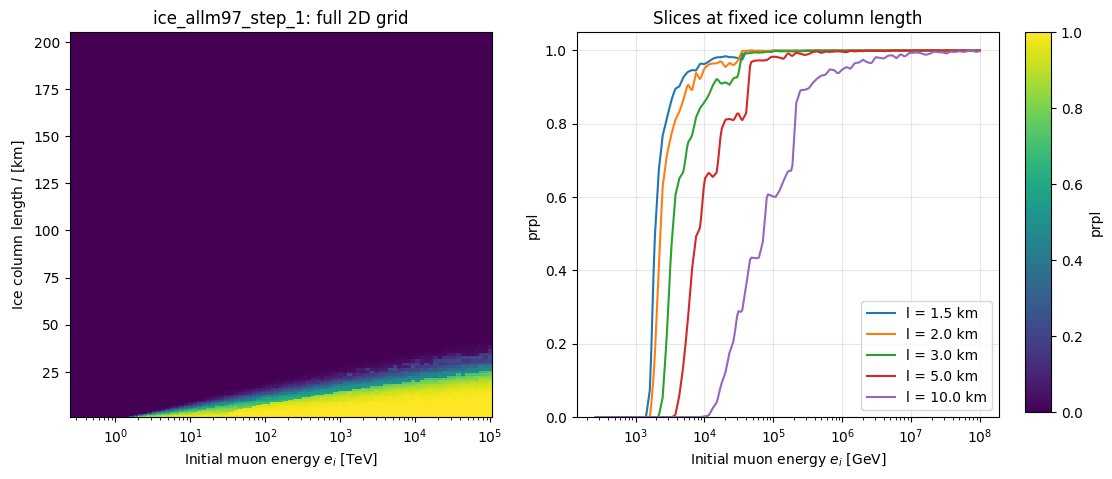

In [23]:
def interp_at_l(l_val, ei_query):
    """Bilinear interpolation of prpl(ei, l) at fixed l, over ei_query."""
    idx = np.searchsorted(l_grid, l_val).clip(1, len(l_grid) - 1)
    t   = (l_val - l_grid[idx - 1]) / (l_grid[idx] - l_grid[idx - 1])
    col = (1 - t) * vals[:, idx - 1] + t * vals[:, idx]
    return np.interp(ei_query, ei_grid, col)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(right=0.84)
cax = fig.add_axes([0.86, 0.12, 0.02, 0.76])

# Left: 2D colour map
pcm = axes[0].pcolormesh(
    ei_grid / 1e3, l_grid / 1e3, vals.T,
    cmap='viridis', vmin=0, vmax=1, shading='auto'
)
fig.colorbar(pcm, cax=cax, label="prpl")
axes[0].set_xscale('log')
axes[0].set_xlabel(r"Initial muon energy $e_i$ [TeV]")
axes[0].set_ylabel("Ice column length $l$ [km]")
axes[0].set_title("ice_allm97_step_1: full 2D grid")

# Right: slices at fixed l
ei_plot  = np.logspace(np.log10(ei_grid.min()), np.log10(ei_grid.max()), 300)
l_samples = [1500, 2000, 3000, 5000, 10000]
for l_val in l_samples:
    axes[1].plot(ei_plot, interp_at_l(l_val, ei_plot), label=f"l = {l_val/1e3:.1f} km")

axes[1].set_xscale('log')
axes[1].set_xlabel(r"Initial muon energy $e_i$ [GeV]")
axes[1].set_ylabel("prpl")
axes[1].set_title("Slices at fixed ice column length")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.savefig("prpl_step1_content.pdf", bbox_inches="tight")
plt.show()